In [1]:
zip_file <- "/content/Uber-Data-Analysis-R.-main.zip"

system2(
  "unzip",
  c("-o", zip_file, "-d", "/content")
)

cat("Đã giải nén!\n")

Đã giải nén!


In [2]:
list.files("/content")


[1] "sample_data"                    "Uber-Data-Analysis-R.-main"    
[3] "Uber-Data-Analysis-R.-main.zip"

In [3]:
setwd("/content/Uber-Data-Analysis-R.-main")

getwd()

list.files("Data")

[1] "/content/Uber-Data-Analysis-R.-main"

[1] "uber-raw-data-apr14.csv" "uber-raw-data-aug14.csv"
[3] "uber-raw-data-jul14.csv" "uber-raw-data-jun14.csv"
[5] "uber-raw-data-may14.csv" "uber-raw-data-sep14.csv"

In [4]:
install.packages("ggplot2")
install.packages("dplyr")
install.packages("scales")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [7]:
getwd()
list.files()
list.files("Data")

[1] "/content/Uber-Data-Analysis-R.-main"

[1] "Data"      "Main.R"    "output"    "R"         "README.md" "Report"

[1] "uber-raw-data-apr14.csv" "uber-raw-data-aug14.csv"
[3] "uber-raw-data-jul14.csv" "uber-raw-data-jun14.csv"
[5] "uber-raw-data-may14.csv" "uber-raw-data-sep14.csv"

In [8]:
file.create("R/04_visualization.R")

[1] TRUE

# 04_visualization.R
# UBER DATA ANALYSIS - VISUALIZATION & HEATMAP

So file du lieu: 6 
Tong so chuyen: 4,534,327 


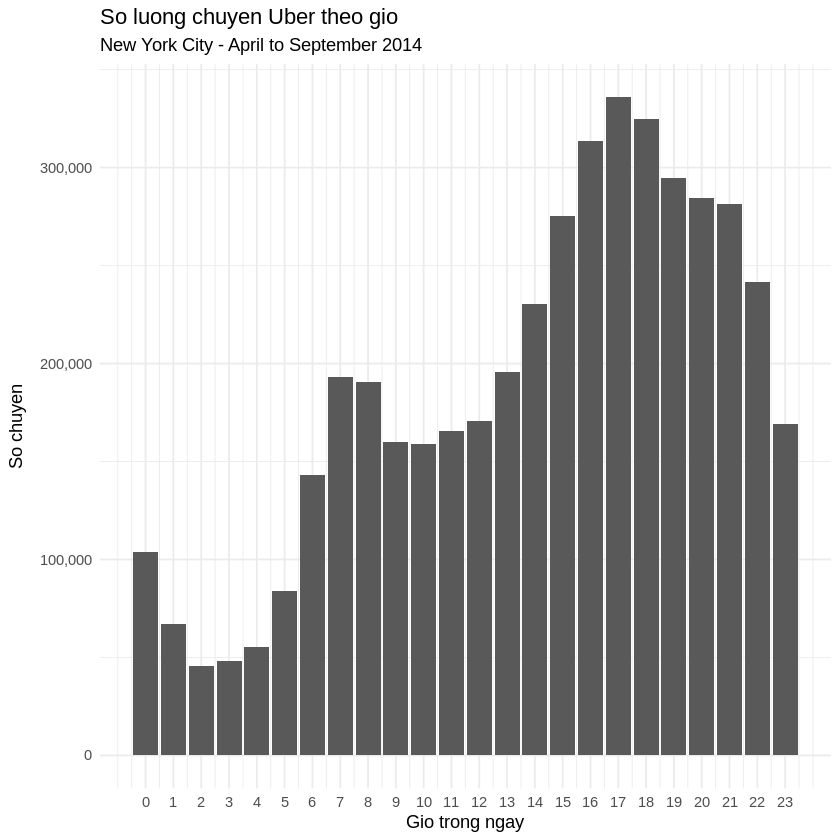

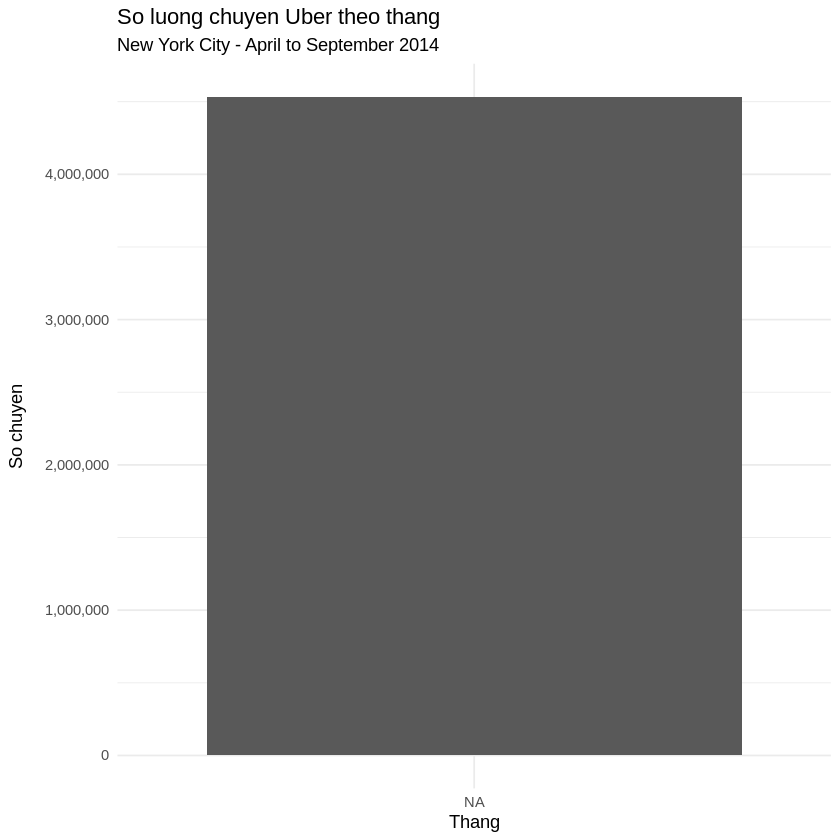

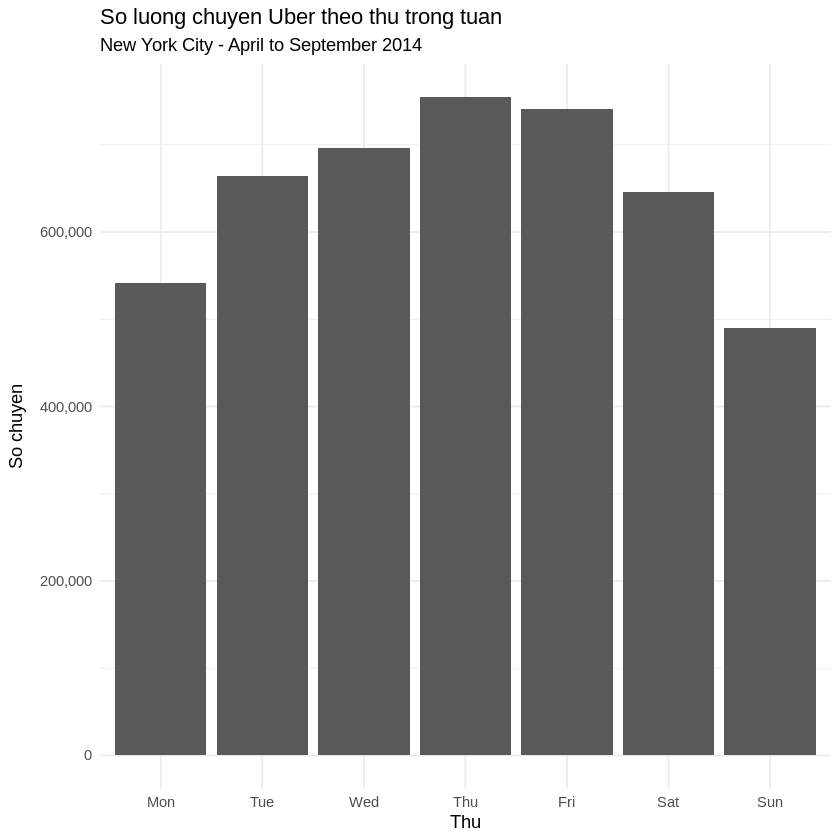


HOAN THANH VISUALIZATION & HEATMAP
Tong so chuyen: 4,534,327 

Gio cao diem:
# A tibble: 1 × 2
   Hour  Trips
  <int>  <int>
1    17 336190

Thang co nhieu chuyen nhat:
# A tibble: 1 × 2
  Month   Trips
  <fct>   <int>
1 NA    4534327

Thứ có nhiều chuyến nhất:
# A tibble: 1 × 2
  Weekday  Trips
  <fct>    <int>
1 Thu     755145

4 bieu do da duoc luu tai:
output/figures/


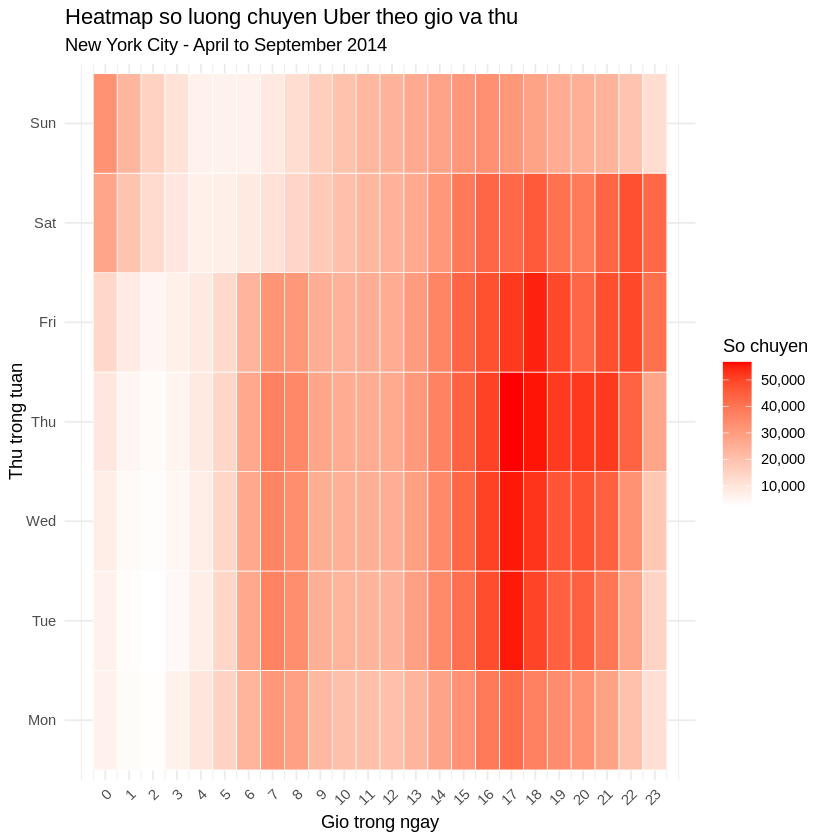

In [13]:
# ============================================================
# 04_visualization.R
# UBER DATA ANALYSIS - VISUALIZATION & HEATMAP
# ============================================================

# Cài thư viện nếu chưa có
if (!require(ggplot2)) install.packages("ggplot2")
if (!require(dplyr)) install.packages("dplyr")
if (!require(scales)) install.packages("scales")

library(ggplot2)
library(dplyr)
library(scales)

# ============================================================
# 1. ĐỌC 6 FILE DỮ LIỆU UBER
# ============================================================

files <- list.files(
  "Data",
  pattern = "uber-raw-data-.*\\.csv$",
  full.names = TRUE
)

cat("So file du lieu:", length(files), "\n")

uber_data <- bind_rows(
  lapply(files, function(file) {

    data <- read.csv(
      file,
      stringsAsFactors = FALSE
    )

    data$Month <- substr(
      basename(file),
      16,
      18
    )

    return(data)
  })
)

cat(
  "Tong so chuyen:",
  format(nrow(uber_data), big.mark = ","),
  "\n"
)

# ============================================================
# 2. XỬ LÝ THỜI GIAN
# ============================================================

uber_data$Date.Time <- as.POSIXct(
  uber_data$Date.Time,
  format = "%m/%d/%Y %H:%M:%S"
)

uber_data$Hour <- as.integer(
  format(uber_data$Date.Time, "%H")
)

uber_data$Weekday <- weekdays(
  uber_data$Date.Time
)

# Đổi sang tên tiếng Anh ngắn
weekday_map <- c(
  "Monday" = "Mon",
  "Tuesday" = "Tue",
  "Wednesday" = "Wed",
  "Thursday" = "Thu",
  "Friday" = "Fri",
  "Saturday" = "Sat",
  "Sunday" = "Sun"
)

uber_data$Weekday <- weekday_map[
  uber_data$Weekday
]

uber_data$Weekday <- factor(
  uber_data$Weekday,
  levels = c(
    "Mon",
    "Tue",
    "Wed",
    "Thu",
    "Fri",
    "Sat",
    "Sun"
  )
)

uber_data$Month <- factor(
  uber_data$Month,
  levels = c(
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep"
  )
)

# ============================================================
# 3. TẠO THƯ MỤC LƯU HÌNH
# ============================================================

dir.create(
  "output/figures",
  recursive = TRUE,
  showWarnings = FALSE
)

# ============================================================
# 4. BIỂU ĐỒ THEO GIỜ
# ============================================================

hour_data <- uber_data %>%
  group_by(Hour) %>%
  summarise(
    Trips = n(),
    .groups = "drop"
  )

p1 <- ggplot(
  hour_data,
  aes(
    x = Hour,
    y = Trips
  )
) +
  geom_col() +
  scale_x_continuous(
    breaks = 0:23
  ) +
  scale_y_continuous(
    labels = comma
  ) +
  labs(
    title = "So luong chuyen Uber theo gio",
    subtitle = "New York City - April to September 2014",
    x = "Gio trong ngay",
    y = "So chuyen"
  ) +
  theme_minimal()

print(p1)

ggsave(
  "output/figures/01_trips_by_hour.png",
  p1,
  width = 10,
  height = 6,
  dpi = 300
)

# ============================================================
# 5. BIỂU ĐỒ THEO THÁNG
# ============================================================

month_data <- uber_data %>%
  group_by(Month) %>%
  summarise(
    Trips = n(),
    .groups = "drop"
  )

p2 <- ggplot(
  month_data,
  aes(
    x = Month,
    y = Trips
  )
) +
  geom_col() +
  scale_y_continuous(
    labels = comma
  ) +
  labs(
    title = "So luong chuyen Uber theo thang",
    subtitle = "New York City - April to September 2014",
    x = "Thang",
    y = "So chuyen"
  ) +
  theme_minimal()

print(p2)

ggsave(
  "output/figures/02_trips_by_month.png",
  p2,
  width = 9,
  height = 6,
  dpi = 300
)

# ============================================================
# 6. BIỂU ĐỒ THEO THỨ
# ============================================================

weekday_data <- uber_data %>%
  group_by(Weekday) %>%
  summarise(
    Trips = n(),
    .groups = "drop"
  )

p3 <- ggplot(
  weekday_data,
  aes(
    x = Weekday,
    y = Trips
  )
) +
  geom_col() +
  scale_y_continuous(
    labels = comma
  ) +
  labs(
    title = "So luong chuyen Uber theo thu trong tuan",
    subtitle = "New York City - April to September 2014",
    x = "Thu",
    y = "So chuyen"
  ) +
  theme_minimal()

print(p3)

ggsave(
  "output/figures/03_trips_by_weekday.png",
  p3,
  width = 9,
  height = 6,
  dpi = 300
)

# ============================================================
# 7. HEATMAP: GIỜ × THỨ
# ============================================================

heatmap_data <- uber_data %>%
  group_by(
    Weekday,
    Hour
  ) %>%
  summarise(
    Trips = n(),
    .groups = "drop"
  )

p4 <- ggplot(
  heatmap_data,
  aes(
    x = Hour,
    y = Weekday,
    fill = Trips
  )
) +
  geom_tile(
    color = "white"
  ) +
  scale_x_continuous(
    breaks = 0:23
  ) +
  scale_fill_gradient(
    low = "white",
    high = "red",
    labels = comma
  ) +
  labs(
    title = "Heatmap so luong chuyen Uber theo gio va thu",
    subtitle = "New York City - April to September 2014",
    x = "Gio trong ngay",
    y = "Thu trong tuan",
    fill = "So chuyen"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(
      angle = 45,
      hjust = 1
    )
  )

print(p4)

ggsave(
  "output/figures/04_heatmap_hour_weekday.png",
  p4,
  width = 14,
  height = 7,
  dpi = 300
)

# ============================================================
# 8. KẾT QUẢ
# ============================================================

cat("\n========================================\n")
cat("HOAN THANH VISUALIZATION & HEATMAP\n")
cat("========================================\n")

cat(
  "Tong so chuyen:",
  format(nrow(uber_data), big.mark = ","),
  "\n"
)

cat("\nGio cao diem:\n")
print(
  hour_data %>%
    slice_max(Trips, n = 1)
)

cat("\nThang co nhieu chuyen nhat:\n")
print(
  month_data %>%
    slice_max(Trips, n = 1)
)

cat("\nThứ có nhiều chuyến nhất:\n")
print(
  weekday_data %>%
    slice_max(Trips, n = 1)
)

cat("\n4 bieu do da duoc luu tai:\n")
cat("output/figures/\n")